In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

Directorio de trabajo actual: e:\ACTUAL\SEMILLERO-PAPER\Git-Hub\NeuroCo_Project\DATA/
Intentando cargar el archivo: e:\ACTUAL\SEMILLERO-PAPER\Git-Hub\NeuroCo_Project\DATA/AD_mean_correlation_matrix.csv
Matriz 'AD_mean_correlation_matrix.csv' cargada para el grupo: AD
Dimensiones de la matriz: (400, 400)
Intentando cargar el archivo: e:\ACTUAL\SEMILLERO-PAPER\Git-Hub\NeuroCo_Project\DATA/CNAD_mean_correlation_matrix.csv
Matriz 'CNAD_mean_correlation_matrix.csv' cargada para el grupo: CNAD
Dimensiones de la matriz: (400, 400)
Intentando cargar el archivo: e:\ACTUAL\SEMILLERO-PAPER\Git-Hub\NeuroCo_Project\DATA/CNMCI_mean_correlation_matrix.csv
Matriz 'CNMCI_mean_correlation_matrix.csv' cargada para el grupo: CNMCI
Dimensiones de la matriz: (400, 400)
Intentando cargar el archivo: e:\ACTUAL\SEMILLERO-PAPER\Git-Hub\NeuroCo_Project\DATA/MCI_mean_correlation_matrix.csv
Matriz 'MCI_mean_correlation_matrix.csv' cargada para el grupo: MCI
Dimensiones de la matriz: (400, 400)


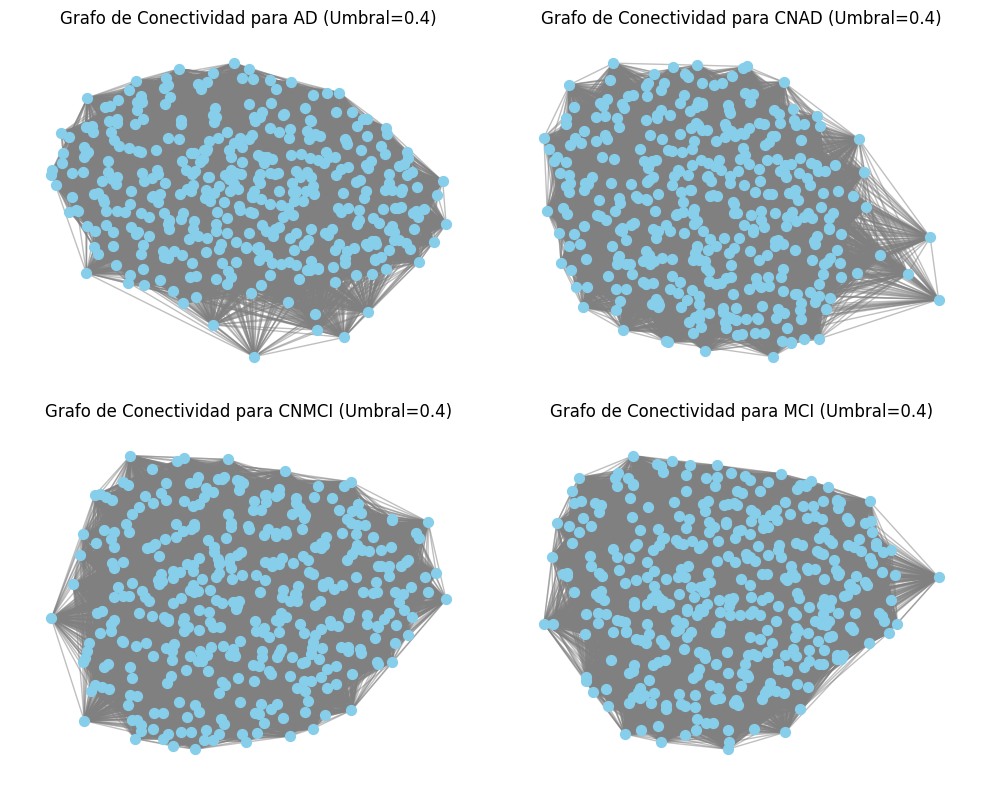

In [ ]:

# --- 1. Cargar las matrices de correlación ---
# Asume que los archivos CSV están en el mismo directorio que este script.
# Si no, especifica la ruta completa a los archivos.
file_names = [
    "AD_mean_correlation_matrix.csv",
    "CNAD_mean_correlation_matrix.csv",
    "CNMCI_mean_correlation_matrix.csv",
    "MCI_mean_correlation_matrix.csv"
]

correlation_matrices = {}

# Imprimir el directorio de trabajo actual para depuración
current_directory = os.getcwd()
complemento = "DATA/"
current_directory = os.path.join(current_directory,complemento)## correcciones locales 
print(f"Directorio de trabajo actual: {current_directory}")

for file_name in file_names:
    # Construir la ruta completa al archivo
    full_file_path = os.path.join(current_directory, file_name)
    print(f"Intentando cargar el archivo: {full_file_path}")

    try:
        # Extraer el nombre del grupo del nombre del archivo (ej. "AD", "CNAD")
        group_name = file_name.split('_')[0]
        # Cargar la matriz de correlación, asumiendo que es un CSV sin encabezado ni índice
        matrix = pd.read_csv(full_file_path, header=None, index_col=None).values
        correlation_matrices[group_name] = matrix
        print(f"Matriz '{file_name}' cargada para el grupo: {group_name}")
        print(f"Dimensiones de la matriz: {matrix.shape}")
    except FileNotFoundError:
        print(f"Error: El archivo '{full_file_path}' no se encontró. Asegúrate de que esté en la ruta correcta o que el script se ejecute desde el directorio correcto.")
    except Exception as e:
        print(f"Ocurrió un error al cargar '{full_file_path}': {e}")

# --- 2. Extraer grafos y plotearlos ---
# Para extraer los grafos, necesitamos un umbral para binarizar la matriz de correlación.
# Las correlaciones por debajo del umbral se considerarán como no-conexiones.
# Un umbral común es 0.3 o 0.4, pero puede variar según el estudio.
threshold = 0.4 ### Ajustar este umbral

plt.figure(figsize=(10, 8))

# Verificar si se cargaron matrices antes de intentar plotear
if not correlation_matrices:
    print("No se cargaron matrices de correlación. No se pueden plotear los grafos.")
else:
    for i, (group_name, matrix) in enumerate(correlation_matrices.items()):
        # Crear una matriz de adyacencia binarizada
        # Convertir a valores absolutos si las correlaciones pueden ser negativas y quieres considerarlas como conexiones
        adj_matrix = (np.abs(matrix) > threshold).astype(int)

        # Crear el grafo a partir de la matriz de adyacencia
        # nx.Graph() para grafos no dirigidos (conexiones simétricas)
        G = nx.from_numpy_array(adj_matrix)

        # Eliminar auto-bucles (conexiones de un nodo consigo mismo) si existen
        G.remove_edges_from(nx.selfloop_edges(G))

        # Plotear el grafo
        plt.subplot(2, 2, i + 1) # 2 filas, 2 columnas para 4 grafos
        pos = nx.spring_layout(G, seed=42) # Diseño de resorte para una buena visualización
        nx.draw_networkx_nodes(G, pos, node_size=50, node_color='skyblue')
        nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color='gray')
        plt.title(f'Grafo de Conectividad para {group_name} (Umbral={threshold})')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:

# --- 3. Aplicar métricas de integración y segregación funcional ---
# Elegiremos 3 métricas principales:
# Integración:
# 1. Longitud de camino promedio (Average Path Length): Mide la eficiencia de la transferencia de información en la red.
# 2. Eficiencia global (Global Efficiency): Una medida alternativa de integración que no requiere que la red esté conectada.
# Segregación:
# 3. Coeficiente de agrupamiento promedio (Average Clustering Coefficient): Mide la tendencia de los nodos a agruparse.

print("\n--- Métricas de Integración y Segregación Funcional ---")
if not correlation_matrices:
    print("No se cargaron matrices de correlación. No se pueden calcular las métricas.")
else:
    for group_name, matrix in correlation_matrices.items():
        adj_matrix = (np.abs(matrix) > threshold).astype(int)
        G = nx.from_numpy_array(adj_matrix)
        G.remove_edges_from(nx.selfloop_edges(G))

        print(f"\nGrupo: {group_name}")

        # Métrica de Integración 1: Longitud de camino promedio
        # Solo es aplicable si el grafo está conectado.
        if nx.is_connected(G):
            avg_path_length = nx.average_shortest_path_length(G)
            print(f"  Longitud de Camino Promedio (Average Path Length): {avg_path_length:.4f}")
        else:
            print("  El grafo no está conectado, no se puede calcular la Longitud de Camino Promedio directamente.")
            # Para grafos desconectados, se puede calcular para cada componente conectado
            # o usar la eficiencia global como una alternativa más robusta.

        # Métrica de Integración 2: Eficiencia Global
        # Esta métrica es más robusta para grafos desconectados.
        global_efficiency = nx.global_efficiency(G)
        print(f"  Eficiencia Global (Global Efficiency): {global_efficiency:.4f}")

        # Métrica de Segregación 3: Coeficiente de Agrupamiento Promedio
        avg_clustering_coefficient = nx.average_clustering(G)
        print(f"  Coeficiente de Agrupamiento Promedio (Average Clustering Coefficient): {avg_clustering_coefficient:.4f}")

        # Otras métricas a considerar:
        # Integración:
        # - Centralidad de intermediación (Betweenness Centrality): Mide la importancia de un nodo como puente.
        # - Centralidad de cercanía (Closeness Centrality): Mide qué tan cerca está un nodo de todos los demás.
        # Segregación:
        # - Modularidad (Modularity): Mide la fuerza de la división de una red en módulos (comunidades).
        # - Transitividad (Transitivity): Otra forma de coeficiente de agrupamiento global.

